# 4. Classification

Multiclass prediction of `Rating` (low / medium / high) with KNN, Gaussian
Naive Bayes and Decision Trees. Features: `YearPublished`, `AvgGameweight`,
`MinPlayers`, `MaxPlayers`, `PopularityScore`, `ComAvgPlaytime_log`,
`ComAgeRec`. 70/30 stratified hold-out split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

df = pd.read_csv("../data/df_clean2.2.csv")
features = ["YearPublished", "AvgGameweight", "MinPlayers", "MaxPlayers",
            "PopularityScore", "ComAvgPlaytime_log", "ComAgeRec"]
classes = ["Low", "Medium", "High"]

X, y = df[features], df["Rating"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
y_train.value_counts(normalize=True).round(3)

Rating
Medium    0.44
Low       0.33
High      0.23
Name: proportion, dtype: float64

## 4.1 K-Nearest Neighbors

KNN is distance-based, so features are standardized. The baseline uses the
rule-of-thumb k = sqrt(N), Euclidean distance and uniform weights; we then try
smaller k, the Manhattan metric and distance weighting.

In [2]:
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

k_base = int(np.sqrt(len(X)))
rows = []
for k in [5, 10, 20, 50, 100, k_base]:
    for metric in ["euclidean", "manhattan"]:
        for weights in ["uniform", "distance"]:
            pred = (KNeighborsClassifier(k, metric=metric, weights=weights)
                    .fit(X_train_s, y_train).predict(X_test_s))
            rows.append([k, metric, weights, accuracy_score(y_test, pred),
                         f1_score(y_test, pred, average="weighted"),
                         f1_score(y_test, pred, average="macro")])
knn_grid = pd.DataFrame(rows, columns=["k", "metric", "weights", "accuracy",
                                       "weighted F1", "macro F1"]).round(3)
knn_grid.sort_values("macro F1", ascending=False).head(8)

,k,metric,weights,accuracy,weighted F1,macro F1
10,20,manhattan,uniform,0.598,0.598,0.595
19,100,manhattan,distance,0.603,0.600,0.593
15,50,manhattan,distance,0.601,0.599,0.593
11,20,manhattan,distance,0.598,0.597,0.593
18,100,manhattan,uniform,0.600,0.598,0.590
14,50,manhattan,uniform,0.598,0.596,0.590
23,148,manhattan,distance,0.599,0.597,0.589
6,10,manhattan,uniform,0.587,0.586,0.586


Performance is remarkably stable: every configuration lands within about two
accuracy points, with the Manhattan variants only marginally ahead. We keep
k = 20 with Euclidean distance and uniform weights as reference model, since
the more elaborate alternatives do not pay for their extra complexity.

In [3]:
knn = KNeighborsClassifier(20).fit(X_train_s, y_train)
print(classification_report(y_test, knn.predict(X_test_s)))

              precision    recall  f1-score   support

        High       0.59      0.49      0.54      1511
         Low       0.61      0.60      0.61      2174
      Medium       0.55      0.60      0.57      2893

    accuracy                           0.58      6578
   macro avg       0.58      0.57      0.57      6578
weighted avg       0.58      0.58      0.58      6578



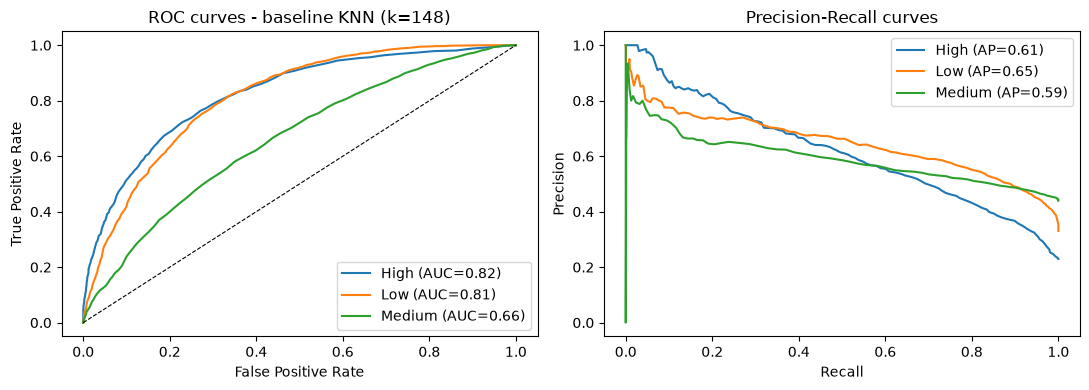

In [4]:
knn_base = KNeighborsClassifier(k_base).fit(X_train_s, y_train)
scores = knn_base.predict_proba(X_test_s)
y_bin = label_binarize(y_test, classes=knn_base.classes_)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, cls in enumerate(knn_base.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
    axes[0].plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
    prec, rec, _ = precision_recall_curve(y_bin[:, i], scores[:, i])
    ap = average_precision_score(y_bin[:, i], scores[:, i])
    axes[1].plot(rec, prec, label=f"{cls} (AP={ap:.2f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=.8)
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
            title=f"ROC curves - baseline KNN (k={k_base})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curves")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

The `Medium` class is the hardest to separate: being adjacent to both other
rating levels, it overlaps with each of them.

## 4.2 Gaussian Naive Bayes

No tuning stage is required; it serves as a simple probabilistic baseline.

              precision    recall  f1-score   support

        High       0.50      0.57      0.53      1511
         Low       0.62      0.43      0.51      2174
      Medium       0.51      0.60      0.55      2893

    accuracy                           0.53      6578
   macro avg       0.55      0.53      0.53      6578
weighted avg       0.55      0.53      0.53      6578



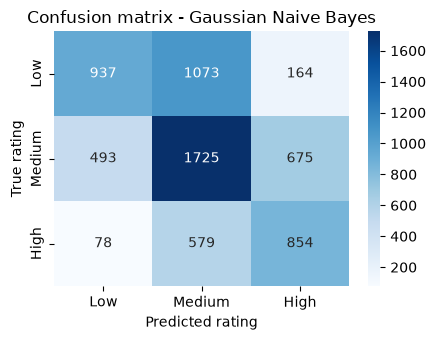

In [5]:
gnb = GaussianNB().fit(X_train, y_train)
pred_gnb = gnb.predict(X_test)
print(classification_report(y_test, pred_gnb))

cm = confusion_matrix(y_test, pred_gnb, labels=classes)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted rating")
plt.ylabel("True rating")
plt.title("Confusion matrix - Gaussian Naive Bayes")
plt.tight_layout()
plt.show()

## 4.3 Decision Tree

A tree grown with default parameters overfits heavily, so we tune depth, split
and leaf parameters with randomized search and 5-fold cross-validation
(pre-pruning).

In [6]:
dt_full = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f"default tree: train acc = {dt_full.score(X_train, y_train):.3f}, "
      f"test acc = {dt_full.score(X_test, y_test):.3f}, "
      f"depth = {dt_full.get_depth()}")

default tree: train acc = 1.000, test acc = 0.577, depth = 33


In [7]:
param_dist = {"criterion": ["gini", "entropy"],
              "max_depth": [4, 6, 8, 10, 12, 16],
              "min_samples_split": [2, 20, 50, 100, 200],
              "min_samples_leaf": [1, 10, 30, 50, 100]}
search = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), param_dist,
                            n_iter=60, cv=5, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
search.best_params_

{'min_samples_split': 100,
 'min_samples_leaf': 30,
 'max_depth': 8,
 'criterion': 'gini'}

In [8]:
dt = search.best_estimator_
pred_dt = dt.predict(X_test)
print(f"train acc = {dt.score(X_train, y_train):.3f}")
print(classification_report(y_test, pred_dt))

train acc = 0.675
              precision    recall  f1-score   support

        High       0.68      0.64      0.66      1511
         Low       0.71      0.63      0.67      2174
      Medium       0.61      0.68      0.64      2893

    accuracy                           0.65      6578
   macro avg       0.66      0.65      0.65      6578
weighted avg       0.66      0.65      0.65      6578



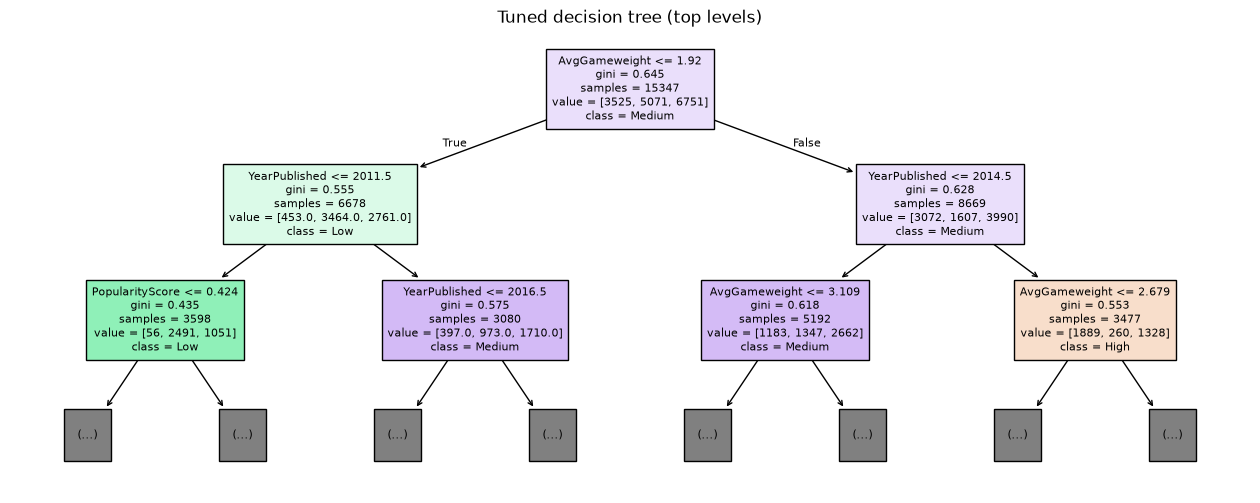

In [9]:
plt.figure(figsize=(16, 6))
plot_tree(dt, max_depth=2, feature_names=features, class_names=dt.classes_,
          filled=True, fontsize=8)
plt.title("Tuned decision tree (top levels)")
plt.show()

The pruned tree closes most of the train/test gap, confirming that limiting
complexity controls overfitting. The first splits use complexity, popularity
and publication year, which is consistent with the correlation analysis.

## 4.4 Performance comparison

In [10]:
rows = []
for name, pred in [("KNN (k=20)", knn.predict(X_test_s)),
                   ("Gaussian Naive Bayes", pred_gnb),
                   ("Decision Tree (tuned)", pred_dt)]:
    rows.append([name, accuracy_score(y_test, pred),
                 f1_score(y_test, pred, average="weighted"),
                 f1_score(y_test, pred, average="macro")])
pd.DataFrame(rows, columns=["model", "accuracy", "weighted F1", "macro F1"]).round(3)

,model,accuracy,weighted F1,macro F1
0,KNN (k=20),0.577,0.577,0.573
1,Gaussian Naive Bayes,0.535,0.533,0.531
2,Decision Tree (tuned),0.652,0.653,0.655


The tuned Decision Tree is the best classifier on this feature set, followed
by KNN; Gaussian Naive Bayes remains a fast but weaker baseline. Confusion is
concentrated between adjacent rating levels, suggesting that the available
features only capture part of what drives the community rating.